# Heat propagation into wet and dry soil profiles

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl

In [2]:
from soilice import model

In [3]:
# Use these commands to write the default parameters and constants to two text files in the working folder
from soilice import writeDefaultPars
writeDefaultPars()

def_pars.txt already exists in local folder


In [4]:
# x=model()
# x.setOpts()
# x.opts

In [5]:
# Soil model options:
opts={'simulateFlow': 0.0,        # no flow simulated
 'gravity': 1.0,                  # gravity not relevant
 'infiltration': 1.0,             # Infiltration not relevant
 'cryoK': 1.0,                    # K based on liquid water content
 'cryoGradient': 0.0,             # Cryosuction gradient not relevant
 'freeDrainage': 0.0,             # Free drainage not relevant
 'simulateTransport': 1.0,        # Yes, simulate transport
 'withadv': 1.0,                  # Simulate advection
 'conductionTop': 0.0,            # No conduction at the top
 'conductionBot': 0.0}            # or the bottom

In [6]:
# Space grid
zMax=2.
dz=0.01
z=np.arange(dz/2,zMax,dz)
nz=len(z)
dz=np.zeros(nz)+dz

# Time grid
t=np.arange(0,10,0.1) # days
nt=len(t)
dt=t[1]-t[0]

In [7]:
# Boundary conditions - mass and heat fluxes:
jTopBC=2e6  # Specified ground heat flux, if used.

In [8]:
sim=model(opts,rtol=1e-8)
sim.zGrid(np.hstack([0,np.cumsum(dz)]))
sim.tGrid(t[0],t[-1],t[1]-t[0])
sim.readPars()
sim.setBCs(jTopBC=jTopBC)

In [9]:
sim.printOpts()
# Run scenarios with different initial conditions
sim.setICs(psi0=-1,T0=-2.5)
run1=sim.run()

sim.setICs(psi0=-10,T0=-2.5)
run2=sim.run()

*************************************************************************
     SUMMARY OF MODEL OPTIONS:
     * No flow
     * Simulating heat transport
     * Included heat advection
     * No conduction on the upper boundary
     * No conduction on the lower boundary
*************************************************************************


                                    iiii  lllllll   iiii
                                   i::::i l:::::l  i::::i
                                    iiii  l:::::l   iiii
                                          l:::::l
    ssssssssss      ooooooooooo   iiiiiii  l::::l iiiiiii     cccccccccccccccc    eeeeeeeeeeee
  ss::::::::::s   oo:::::::::::oo i:::::i  l::::l i:::::i   cc:::::::::::::::c  ee::::::::::::ee
ss:::::::::::::s o:::::::::::::::o i::::i  l::::l  i::::i  c:::::::::::::::::c e::::::eeeee:::::ee
s::::::ssss:::::so:::::ooooo:::::o i::::i  l::::l  i::::i c:::::::cccccc:::::ce::::::e     e:::::e
 s:::::s  ssssss o::::o     o::::o i::::i 

*************************************************************************
     soilice ran successfully!
               runtime:      9.81 seconds


   Energy balance rmse:  3.35e+02 J
                  bias:  5.27e+02 J
*************************************************************************


                                    iiii  lllllll   iiii
                                   i::::i l:::::l  i::::i
                                    iiii  l:::::l   iiii
                                          l:::::l
    ssssssssss      ooooooooooo   iiiiiii  l::::l iiiiiii     cccccccccccccccc    eeeeeeeeeeee
  ss::::::::::s   oo:::::::::::oo i:::::i  l::::l i:::::i   cc:::::::::::::::c  ee::::::::::::ee
ss:::::::::::::s o:::::::::::::::o i::::i  l::::l  i::::i  c:::::::::::::::::c e::::::eeeee:::::ee
s::::::ssss:::::so:::::ooooo:::::o i::::i  l::::l  i::::i c:::::::cccccc:::::ce::::::e     e:::::e
 s:::::s  ssssss o::::o     o::::o i::::i  l::::l  i::::i c::::::c     ccccccce:::::::eeeee::::::e
   s::::::s      o::::o     o::::o i::::i  l::::l  i::::i c:::::c             e:::::::::::::::::e
      s::::::s   o::::o     o::::o i::::i  

*************************************************************************
     soilice ran successfully!
               runtime:      1.27 seconds
   Energy balance rmse:  4.26e+02 J
                  bias:  6.63e+02 J
*************************************************************************



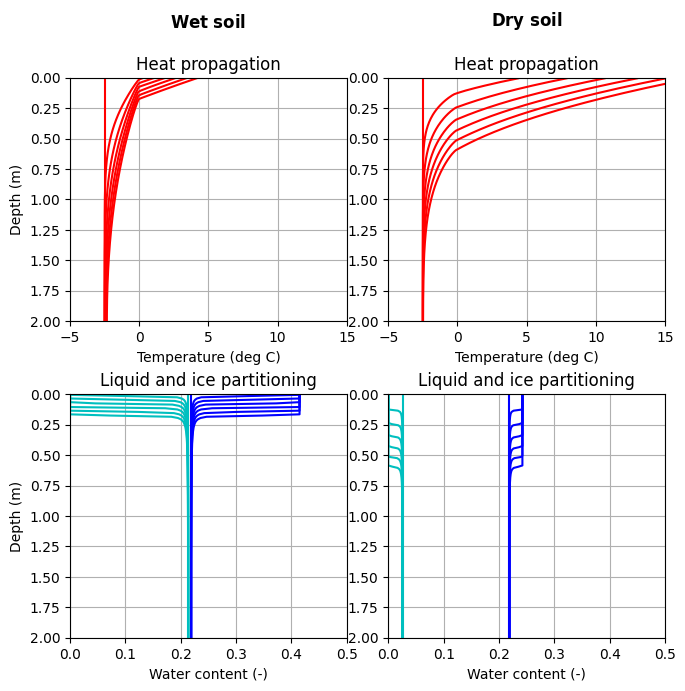

In [10]:
i=np.arange(0,len(t),15)
pl.figure(figsize=(7,7))

pl.subplot(2,2,1)
pl.plot(run1.T[i,:].T,run1.z,'-r')
pl.ylim(2,0)
pl.xlim(-5,15)
pl.grid()
pl.ylabel('Depth (m)')
pl.xlabel('Temperature (deg C)')
pl.title('$\\bf{Wet}$ $\\bf{soil}$\n\nHeat propagation')

pl.subplot(2,2,2)
pl.plot(run2.T[i,:].T,run2.z,'-r')
pl.ylim(2,0)
pl.xlim(-5,15)
pl.grid()
pl.xlabel('Temperature (deg C)')
pl.title('$\\bf{Dry}$ $\\bf{soil}$\n\nHeat propagation')

pl.subplot(2,2,3)
pl.plot(run1.thetaL[i,:].T,run1.z,'-b')
pl.plot(run1.thetaI[i,:].T,run1.z,'-c')
pl.ylim(2,0)
pl.xlim(0, 0.5)
pl.grid()
pl.ylabel('Depth (m)')
pl.xlabel('Water content (-)')
pl.title('Liquid and ice partitioning')

pl.subplot(2,2,4)
pl.plot(run2.thetaL[i,:].T,run2.z,'-b')
pl.plot(run2.thetaI[i,:].T,run2.z,'-c')
pl.ylim(2,0)
pl.xlim(0, 0.5)
pl.grid()
pl.xlabel('Water content (-)')
pl.title('Liquid and ice partitioning')

pl.gcf().subplots_adjust(
    left=0.1, right=0.95,
    top=0.9, bottom=0.1,
    hspace=0.3, wspace=0.15
)

pl.savefig('figures/01_heatPropagation.svg')
pl.show()